A Python notebook to compare results based on same enforced spans across three different datasets with our NER types.


BioDivNER: 
```shell
"DATA/LABEL_STUDIO/LS_BIODIVNER/project-34-at-2025-12-08-13-44-2171ef2d.json"
```

ClimateIE: 
```shell
"DATA/LABEL_STUDIO/LS_CLIMATEIE/project-35-at-2025-12-05-07-53-b0139f8e.json"
```

Climate Change NER (IBM): 
```shell
"DATA/LABEL_STUDIO/LS_IBMCCNER/project-36-at-2025-12-08-13-43-e4ba28f1.json"
```

In [1]:
from dataset_processing import cwed4eta_process_json_file
import json 

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [13]:

def generate_label_distribution_report(
    user_dataset, 
    original_dataset, 
    output_dir="RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/",
    og_dataset_name="BioDivNER",
    map_dataset_name="CliReNER",
    filename_prefix="biodivner_distribution"
):
    """
    Compares label distributions between two annotated datasets with fixed entity spans.
    Generates CSV tables and a Heatmap plot.
    
    Args:
        user_dataset (list): List of dicts (User version, flat structure).
        original_dataset (list): List of dicts (Original version, nested 'data' key).
        output_dir (str): Path to save results.
        filename_prefix (str): Prefix for generated files.
    """
    
    # 1. Setup Directory
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created directory: {output_dir}")

    # 2. Extract and Align Labels
    mapping_data = []
    
    # We assume lists are sorted and aligned by document ID
    for user_doc, og_doc_wrapper in zip(user_dataset, original_dataset):
        
        # Handle structural differences based on your provided schema
        # Original: wrapped in ["data"]
        # User: direct access
        og_entities = og_doc_wrapper.get("data", {}).get("entities", [])
        user_entities = user_doc.get("entities", [])

        # Create Lookup for Original: Key = (start, end), Value = Label
        og_lookup = {
            (e['start'], e['end']): e['label'] 
            for e in og_entities
        }
        
        # Match User entities to Original
        for user_ent in user_entities:
            span_key = (user_ent['start'], user_ent['end'])
            
            if span_key in og_lookup:
                mapping_data.append({
                    "Original_Label": og_lookup[span_key],
                    "User_Label": user_ent['label'],
                    "Entity_Text": user_ent["text"]
                })

    if not mapping_data:
        print("No matching spans found between datasets.")
        return

    df_map = pd.DataFrame(mapping_data)

    # 3. Generate Matrices
    
    # A. Raw Counts
    count_matrix = pd.crosstab(
        df_map["Original_Label"], 
        df_map["User_Label"]
    )
    
    # B. Percentages (Row-wise normalization)
    # This shows: Of all [Original_Row] entities, X% became [User_Col]
    pct_matrix = pd.crosstab(
        df_map["Original_Label"], 
        df_map["User_Label"], 
        normalize='index'
    )
    pct_matrix = (pct_matrix * 100).round(2)

    # 4. Save Tables to CSV
    count_csv_path = os.path.join(output_dir, f"{filename_prefix}_counts.csv")
    pct_csv_path = os.path.join(output_dir, f"{filename_prefix}_percentages.csv")
    
    count_matrix.to_csv(count_csv_path)
    pct_matrix.to_csv(pct_csv_path)
    
    print(f"Saved Count Table: {count_csv_path}")
    print(f"Saved Percentage Table: {pct_csv_path}")

    # 5. Generate and Save Heatmap Plot
    # Dynamic sizing: 
    # Width = number of user labels * 0.8 (min 10)
    # Height = number of original labels * 0.8 (min 8)
    h_w = max(10, len(pct_matrix.columns) * 0.8)
    h_h = max(8, len(pct_matrix.index) * 0.8)

    plt.figure(figsize=(h_w, h_h))
    
    sns.heatmap(
        pct_matrix, 
        annot=True,         # Write the percentage in the box
        fmt='.1f',          # Format to 1 decimal place
        cmap="Oranges",      # Yellow-Green-Blue colormap
        linewidths=.5,      # Space between squares
        cbar_kws={'label': 'Percentage (%)'}
    )
    
    # plt.title("Label Transition Matrix: Original vs User Annotations")
    plt.ylabel(f"{og_dataset_name} Lables")
    plt.xlabel(f"{map_dataset_name} Labels")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    plot_path = os.path.join(output_dir, f"{filename_prefix}_heatmap.png")
    plt.savefig(plot_path, dpi=300)
    plt.close() # Close plot to free memory
    
    print(f"Saved Heatmap Plot: {plot_path}")
    
    return df_map


In [3]:
BioDivNER_DIR =  "DATA/LABEL_STUDIO/LS_BIODIVNER/project-34-at-2025-12-08-13-44-2171ef2d.json"
ClimateIE_DIR = "DATA/LABEL_STUDIO/LS_CLIMATEIE/project-35-at-2025-12-05-07-53-b0139f8e.json"
Climate_Change_NER_DIR = "DATA/LABEL_STUDIO/LS_IBMCCNER/project-36-at-2025-12-08-13-43-e4ba28f1.json"

### BioDivNER

In [14]:
biodivner = cwed4eta_process_json_file(BioDivNER_DIR)
with open("RESULTS/OTHER_DATASETS_ANNOTATIONS/golden_50_Env_Loc_Org_Mat_Phe_Qua.json", "r") as f:
    biodivner_og = json.load(f)

df_map = generate_label_distribution_report(biodivner, biodivner_og)

Saved Count Table: RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/biodivner_distribution_counts.csv
Saved Percentage Table: RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/biodivner_distribution_percentages.csv
Saved Heatmap Plot: RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/biodivner_distribution_heatmap.png


,Original_Label,User_Label,Entity_Text
71,Environment,Method,ground
82,Environment,Method,ground


### ClimateIE

In [33]:
climateie = cwed4eta_process_json_file(ClimateIE_DIR)
with open("RESULTS/OTHER_DATASETS_ANNOTATIONS/golden_50_Mod_WeaEve_Ins_OceCir_Tel_Pro_NatHaz_Pro_Loc_Var.json", "r") as f:
    climateie_og = json.load(f)

df_map = generate_label_distribution_report(climateie, climateie_og, og_dataset_name="ClimateIE", filename_prefix="climatie_distribution")

Saved Count Table: RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/climatie_distribution_counts.csv
Saved Percentage Table: RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/climatie_distribution_percentages.csv
Saved Heatmap Plot: RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/climatie_distribution_heatmap.png


In [36]:
df_map[(df_map.Original_Label == "experiment") &  (df_map.User_Label == "Policy")]

,Original_Label,User_Label,Entity_Text
67,experiment,Policy,RCP4.5
69,experiment,Policy,RCP8.5
71,experiment,Policy,RCP4.5
73,experiment,Policy,RCP8.5
313,experiment,Policy,RCP4.5
315,experiment,Policy,RCP8.5
317,experiment,Policy,RCP4.5
319,experiment,Policy,RCP8.5
326,experiment,Policy,RCP4.5
328,experiment,Policy,RCP8.5


### Climate Change NER (IBM)


In [30]:
ibmccner = cwed4eta_process_json_file(Climate_Change_NER_DIR)
with open("RESULTS/OTHER_DATASETS_ANNOTATIONS/golden_50_Cli_Cli_Cli_Cli_Cli_Cli_Cli_Cli_Cli_Cli_Cli_Cli_Cli.json", "r") as f:
    ibmccner_og = json.load(f)

df_map = generate_label_distribution_report(ibmccner, ibmccner_og, og_dataset_name="Climate Change NER", filename_prefix="ibmccner_distribution")


Saved Count Table: RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/ibmccner_distribution_counts.csv
Saved Percentage Table: RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/ibmccner_distribution_percentages.csv
Saved Heatmap Plot: RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/ibmccner_distribution_heatmap.png


In [32]:
df_map[(df_map.Original_Label == "climate-impacts") &  (df_map.User_Label == "Other")]

,Original_Label,User_Label,Entity_Text
4,climate-impacts,Other,disastrous
79,climate-impacts,Other,damage
153,climate-impacts,Other,deaths
155,climate-impacts,Other,homeless
526,climate-impacts,Other,eco - livelihood impacts
529,climate-impacts,Other,economic losses
713,climate-impacts,Other,health effects
757,climate-impacts,Other,disruption
761,climate-impacts,Other,disruptions
772,climate-impacts,Other,traffic disruptions


# Additionl Visuals

Plot saved to combined_dotplot_final.pdf


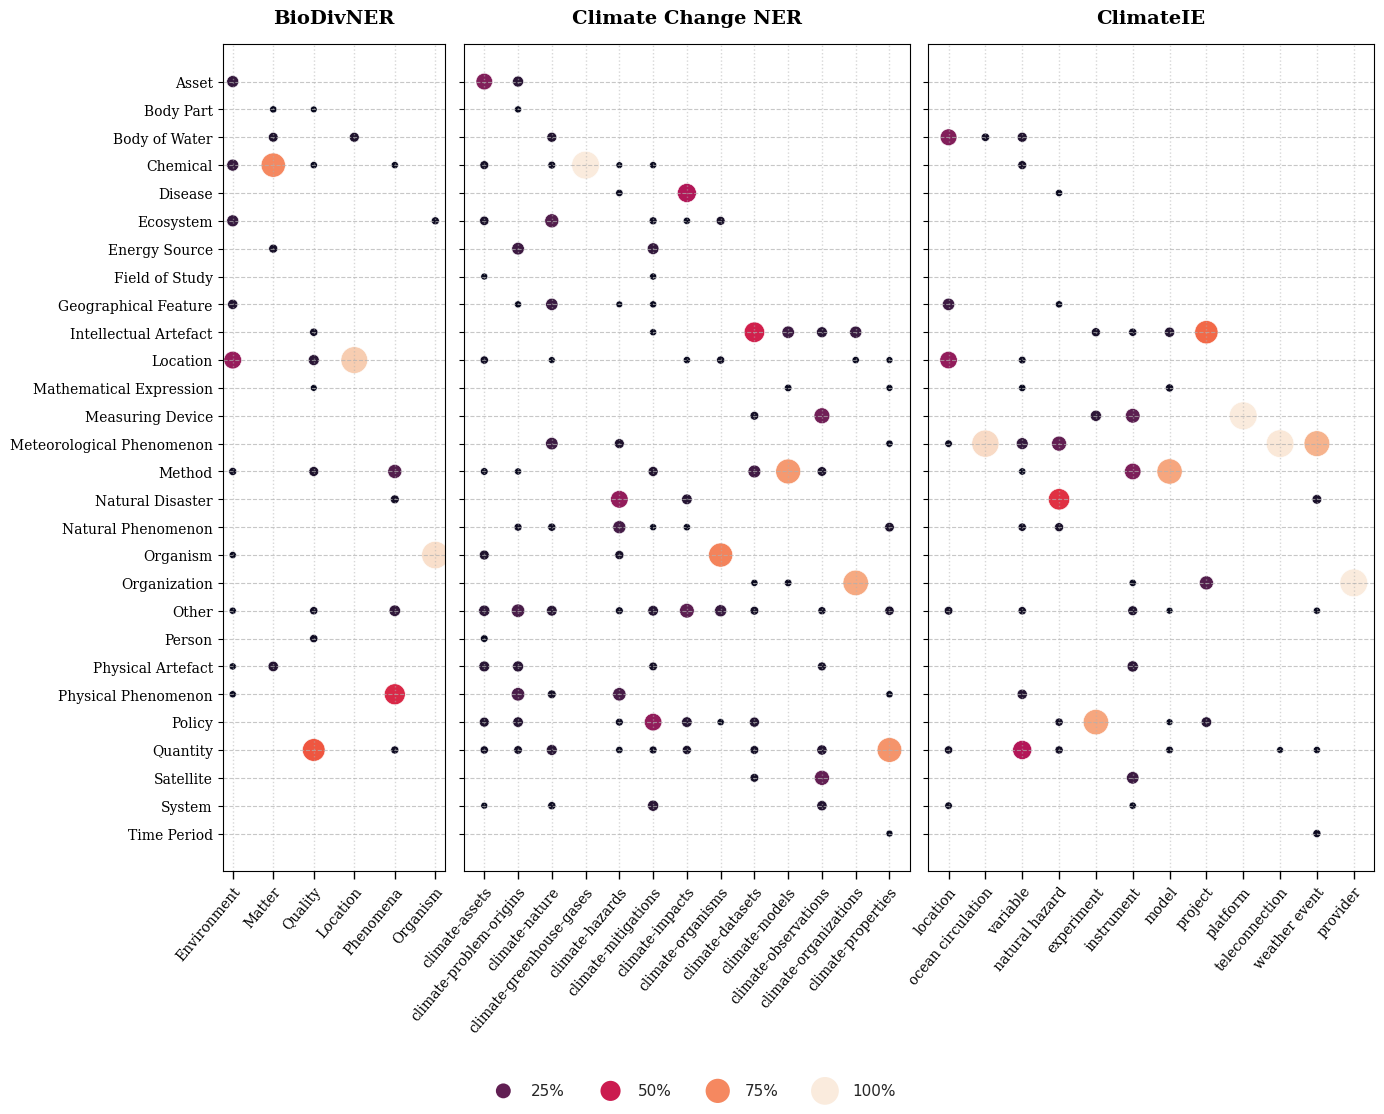

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. CONFIGURATION
# ----------------
files = {
    'BioDivNER': 'RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/biodivner_distribution_percentages.csv',
    'Climate Change NER': 'RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/ibmccner_distribution_percentages.csv',
    'ClimateIE': 'RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/climatie_distribution_percentages.csv'
}

THRESHOLD_PERCENT = 1.0 
DOT_SIZE_MIN = 20
DOT_SIZE_MAX = 400
FIG_SIZE = (14, 11) 

def load_data(filepath, dataset_name):
    try:
        df = pd.read_csv(filepath, sep=None, engine='python') 
    except:
        return None

    id_col = df.columns[0]
    value_cols = df.columns[1:]

    df_long = df.melt(id_vars=[id_col], value_vars=value_cols, 
                      var_name='Target_Label', value_name='Percentage')
    
    df_long = df_long[df_long['Percentage'] >= THRESHOLD_PERCENT].copy()
    df_long['Dataset'] = dataset_name
    df_long.rename(columns={id_col: 'Original_Label'}, inplace=True)
    
    return df_long

# 2. DATA PROCESSING
# ------------------
dfs = []
all_target_labels = set()

for name, path in files.items():
    df = load_data(path, name)
    if df is not None:
        dfs.append(df)
        all_target_labels.update(df['Target_Label'].unique())

sorted_y_labels = sorted(list(all_target_labels))

for df in dfs:
    df['Target_Label'] = pd.Categorical(
        df['Target_Label'], 
        categories=sorted_y_labels, 
        ordered=True
    )

# 3. VISUALIZATION
# ----------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

fig, axes = plt.subplots(1, 3, figsize=FIG_SIZE, sharey=True, 
                         gridspec_kw={'width_ratios': [1, 2, 2]}) 

sns.set_theme(style="whitegrid")

for ax, df in zip(axes, dfs):
    dataset_name = df['Dataset'].iloc[0]
    
    sns.scatterplot(
        data=df,
        x='Original_Label',
        y='Target_Label', 
        size='Percentage',
        sizes=(DOT_SIZE_MIN, DOT_SIZE_MAX),
        hue='Percentage',
        palette='rocket',
        size_norm=(0, 100),
        hue_norm=(0, 100),
        legend=False,
        ax=ax
    )

    ax.set_title(dataset_name, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # Angled labels with right alignment (fixes overlap)
    ax.tick_params(axis='x', bottom=True, length=6, width=1, color='black')
    plt.setp(ax.get_xticklabels(), rotation=50, ha='right', rotation_mode="anchor")

    # Dotted vertical lines to see columns better
    ax.grid(True, axis='x', linestyle=':', linewidth=1, alpha=0.5)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# 4. GLOBAL ADJUSTMENTS
# ---------------------
axes[0].set_yticks(range(len(sorted_y_labels)))
axes[0].set_yticklabels(sorted_y_labels)

# --- COLORED LEGEND FIX ---
# Get the 'rocket' colormap object
cmap = sns.color_palette("rocket", as_cmap=True)

dummy_sizes = [25, 50, 75, 100]

# We map the percentage (s) to the colormap (0.0 to 1.0)
legend_markers = [
    plt.scatter(
        [], [], 
        s=np.interp(s, [0, 100], [DOT_SIZE_MIN, DOT_SIZE_MAX]), 
        color=cmap(s / 100.0),  # This applies the 'rocket' color
        edgecolor='none',       # Remove outline for cleaner look
        label=f'{s}%'
    ) 
    for s in dummy_sizes
]

# Create the legend
fig.legend(handles=legend_markers, 
           loc='upper center', bbox_to_anchor=(0.5, 0.02), 
           ncol=4, frameon=False)

# Tight layout + Manual spacing adjustment
plt.tight_layout()
plt.subplots_adjust(bottom=0.2, wspace=0.05) # wspace=0.05 closes the gap between plots

output_filename = 'combined_dotplot_final.pdf'
plt.savefig(output_filename, bbox_inches='tight', dpi=300)
print(f"Plot saved to {output_filename}")
plt.show()

In [ ]:
!pip install plotly kaleido

In [34]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. CONFIGURATION
# ----------------
files = {
    'BioDivNER': 'RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/biodivner_distribution_percentages.csv',
    'IBMCCNER': 'RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/ibmccner_distribution_percentages.csv',
    'ClimateIE': 'RESULTS/OTHER_DATASETS_ANNOTATIONS/OVERLAPS/climatie_distribution_percentages.csv'
}

THRESHOLD_PERCENT = 1.0  # Filter out < 1%
OPACITY = 0.4            # Transparency of the flow links

def load_data(filepath):
    try:
        df = pd.read_csv(filepath, sep=None, engine='python')
    except:
        return None
    
    # Identify structure
    id_col = df.columns[0]
    value_cols = df.columns[1:]
    
    # Melt to Long Format (Source -> Target -> Value)
    df_long = df.melt(id_vars=[id_col], value_vars=value_cols, 
                      var_name='Target', value_name='Value')
    
    # Filter small values
    df_long = df_long[df_long['Value'] >= THRESHOLD_PERCENT].copy()
    df_long.rename(columns={id_col: 'Source'}, inplace=True)
    
    return df_long

# 2. DATA PREPARATION FOR PLOTLY
# ------------------------------
# Plotly Sankey requires data in "Node Indices" (0, 1, 2...) not names.
# We process each dataset independently to create 3 separate Sankeys.

figs_data = []

for name, filepath in files.items():
    df = load_data(filepath)
    if df is None: continue
    
    # 1. Get unique labels for this specific dataset
    # We append a unique suffix so "Location" on the Left doesn't mix with "Location" on the Right
    sources = df['Source'].unique().tolist()
    targets = df['Target'].unique().tolist()
    
    # Create a unified list of labels for the nodes
    # Structure: [All Source Labels, All Target Labels]
    all_nodes = sources + targets
    
    # Map string labels to integer indices (0 to N)
    source_indices = [sources.index(s) for s in df['Source']]
    # Target indices must be offset by the number of source nodes
    target_indices = [len(sources) + targets.index(t) for t in df['Target']]
    
    # Colors: Let's make Source nodes colored and Target nodes distinct
    # You can define custom palettes here if needed.
    
    figs_data.append({
        'name': name,
        'label': all_nodes,
        'source': source_indices,
        'target': target_indices,
        'value': df['Value'],
        'color_node': ["#1f77b4"] * len(sources) + ["#E58606"] * len(targets) # Blue Left, Orange Right
    })

# 3. VISUALIZATION
# ----------------
fig = go.Figure()

# We stack them using the "domain" parameter.
# y=[0, 1] is the full height.
# Top Plot: y=[0.70, 1.00]
# Mid Plot: y=[0.35, 0.65]
# Bot Plot: y=[0.00, 0.30]

domains = [
    {'x': [0, 1], 'y': [0.72, 1.0]}, # BioDivNER
    {'x': [0, 1], 'y': [0.36, 0.64]}, # IBMCCNER
    {'x': [0, 1], 'y': [0.0, 0.28]}   # ClimateIE
]

annotations = []

for i, data in enumerate(figs_data):
    
    # Add the Sankey Trace
    fig.add_trace(go.Sankey(
        domain=domains[i],
        orientation="h",
        valueformat=".1f",
        valuesuffix="%",
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=data['label'],
            color=data['color_node']
        ),
        link=dict(
            source=data['source'],
            target=data['target'],
            value=data['value'],
            color='rgba(100, 100, 100, 0.2)' # Light gray flows
        )
    ))

    # Add Titles manually (Plotly Sankeys don't support standard subplots well)
    # We place a text annotation above each diagram
    annotations.append(dict(
        x=0.5, 
        y=domains[i]['y'][1] + 0.01, # Slightly above the top of the domain
        text=f"<b>{data['name']}</b>",
        showarrow=False,
        font=dict(size=16, color="black")
    ))

# 4. GLOBAL LAYOUT
# ----------------
fig.update_layout(
    title_text="",
    font_size=12,
    width=1000,
    height=1200, # Tall chart to fit 3 stacks
    annotations=annotations,
    showlegend=False,
    margin=dict(l=20, r=20, t=50, b=20)
)

# 5. EXPORT
# ---------
# Save as PDF for your paper
output_filename = "combined_sankey_distribution.pdf"
try:
    fig.write_image(output_filename)
    print(f"Saved to {output_filename}")
except ValueError as e:
    print("Error saving image. Make sure 'kaleido' is installed: pip install -U kaleido")

# Also save an interactive HTML just in case you want to zoom in/inspect
fig.write_html("combined_sankey_distribution.html")
print("Saved interactive version to combined_sankey_distribution.html")

Error saving image. Make sure 'kaleido' is installed: pip install -U kaleido
Saved interactive version to combined_sankey_distribution.html


/home/p0l3/miniforge3/envs/clirener_finetune/lib/python3.10/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.


